In [1]:
from pathlib import Path
from cellbender.remove_background.downstream import load_anndata_from_input_and_output
import scanpy as sc

In [10]:
BATCH = 1
tissue = "blood"
PT = "PT-201"
side = "L"

if BATCH == 1:
    batch_path = Path("../LBP_brain_blood_pairs/data/narsad_cellRanger_outs/")
else:
    batch_path = Path()

file_path = batch_path / tissue / f"{PT}-blood-{side}"
adata = load_anndata_from_input_and_output(
    input_file=file_path / "raw_feature_bc_matrix.h5",
    output_file=file_path / f"{PT}-{side}-B_CellBender.h5",
)
adata_filtered = load_anndata_from_input_and_output(
    input_file=file_path / "raw_feature_bc_matrix.h5",
    output_file=file_path / f"{PT}-{side}-B_CellBender_filtered.h5",
)

Assuming we are loading a "filtered" file that contains only cells.


In [11]:
adata, adata_filtered

(AnnData object with n_obs × n_vars = 9931 × 36601
     obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_cellranger', 'n_cellbender'
     var: 'ambient_expression', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed', 'n_cellranger', 'n_cellbender'
     uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'features_analyzed_inds', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
     obsm: 'cellbender_embedding'
     layers: 'cellranger', 'cellbender',
 AnnData object with n_obs × n_vars = 3468 × 36601
     obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_cellranger', 'n_cellbender'
     var: 'ambient_expre

In [12]:
adata.layers["cellbender"]

<9931x36601 sparse matrix of type '<class 'numpy.int64'>'
	with 5551914 stored elements in Compressed Sparse Row format>

In [13]:
# preprocess raw data
adata.X = adata.layers["cellranger"].copy()
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3")
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=20, use_highly_variable=True)
sc.pp.neighbors(adata, use_rep="X_pca")

# UMAP of raw data
sc.tl.umap(adata)
adata.obsm["X_umap_raw"] = adata.obsm["X_umap"].copy()

# preprocess cellbender data
adata.X = adata.layers["cellbender"].copy()
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3")
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=20, use_highly_variable=True)
sc.pp.neighbors(adata, use_rep="X_pca")

# UMAP of raw data
sc.tl.umap(adata)
adata.obsm["X_umap_cellbender"] = adata.obsm["X_umap"].copy()

del adata.obsm["X_umap"]

/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


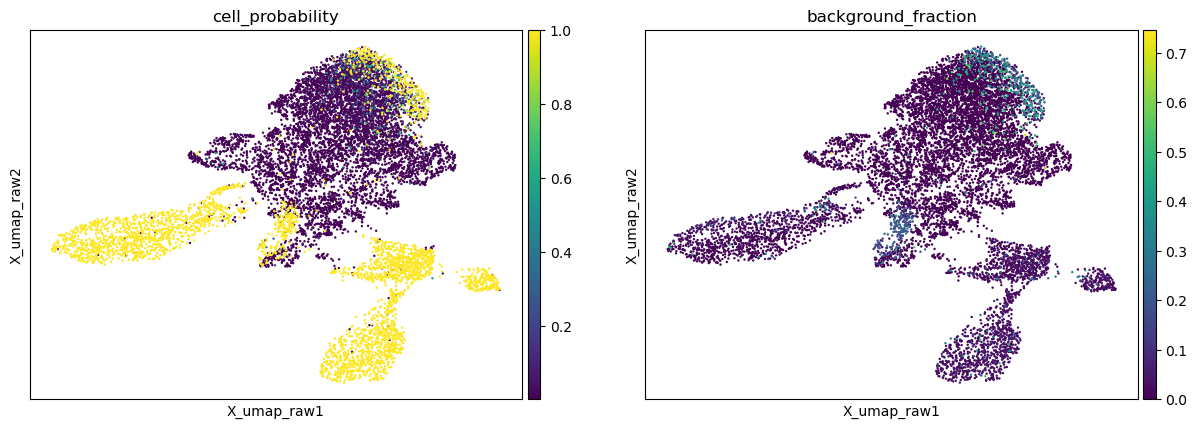

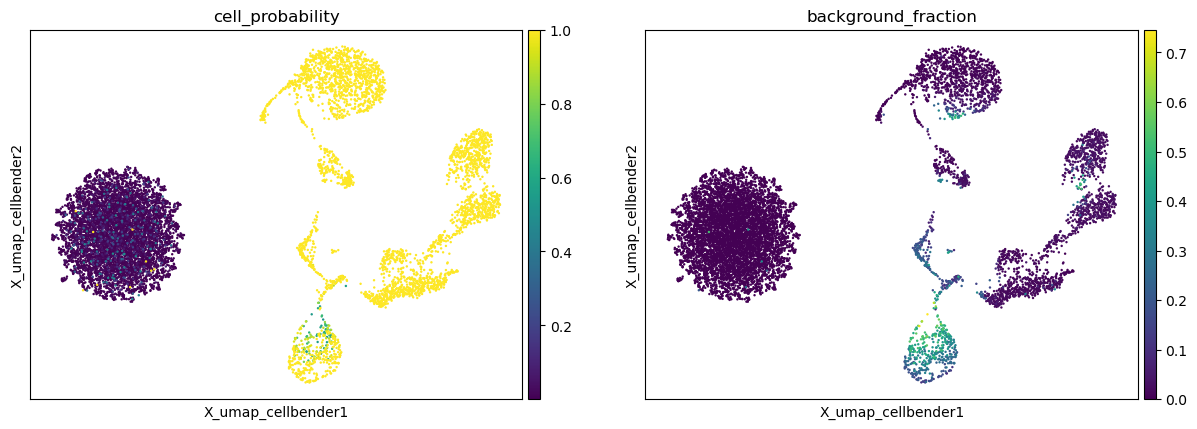

In [14]:
sc.pl.embedding(
    adata, basis="X_umap_raw", color=["cell_probability", "background_fraction"]
)
sc.pl.embedding(
    adata, basis="X_umap_cellbender", color=["cell_probability", "background_fraction"]
)

In [15]:
# preprocess raw data
adata_filtered.X = adata_filtered.layers["cellranger"].copy()
sc.pp.highly_variable_genes(adata_filtered, n_top_genes=3000, flavor="seurat_v3")
sc.pp.normalize_total(adata_filtered)
sc.pp.log1p(adata_filtered)
sc.tl.pca(adata_filtered, n_comps=20, use_highly_variable=True)
sc.pp.neighbors(adata_filtered, use_rep="X_pca")

# UMAP of raw data
sc.tl.umap(adata_filtered)
adata_filtered.obsm["X_umap_raw"] = adata_filtered.obsm["X_umap"].copy()

# preprocess cellbender data
adata_filtered.X = adata_filtered.layers["cellbender"].copy()
sc.pp.highly_variable_genes(adata_filtered, n_top_genes=3000, flavor="seurat_v3")
sc.pp.normalize_total(adata_filtered)
sc.pp.log1p(adata_filtered)
sc.tl.pca(adata_filtered, n_comps=20, use_highly_variable=True)
sc.pp.neighbors(adata_filtered, use_rep="X_pca")

# UMAP of raw data
sc.tl.umap(adata_filtered)
adata_filtered.obsm["X_umap_cellbender"] = adata_filtered.obsm["X_umap"].copy()

del adata_filtered.obsm["X_umap"]

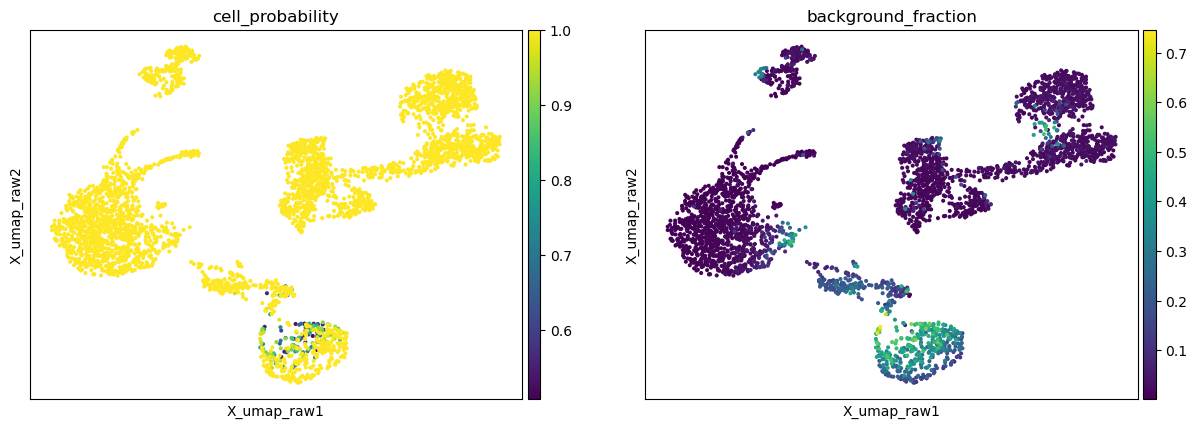

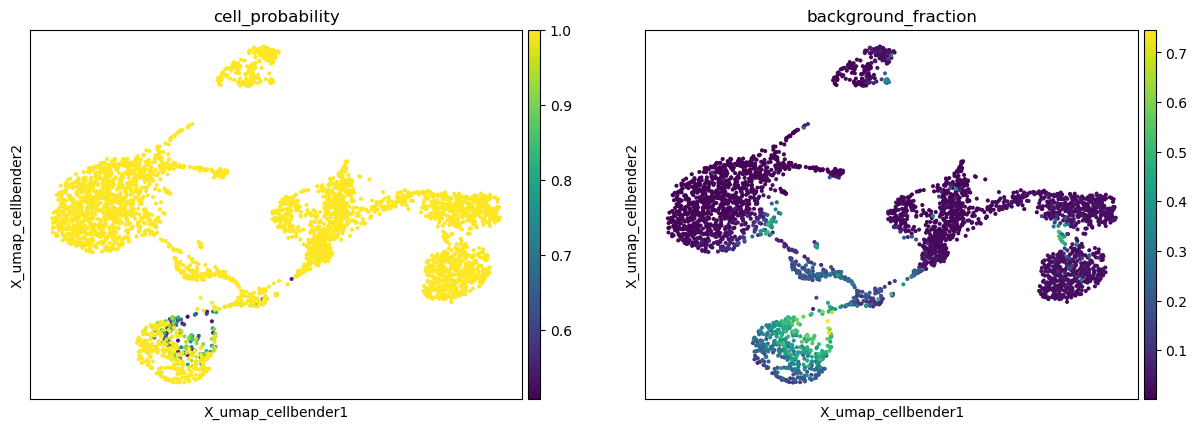

In [16]:
sc.pl.embedding(
    adata_filtered,
    basis="X_umap_raw",
    color=["cell_probability", "background_fraction"],
)
sc.pl.embedding(
    adata_filtered,
    basis="X_umap_cellbender",
    color=["cell_probability", "background_fraction"],
)

In [9]:
adata_filtered.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_cellranger,n_cellbender
barcode,,,,,,
GATTCAGGTCCAACTA-1,0.000684,0.999955,7434.538574,2.227736,16084,16073
CTCTACGTCAGGTAAA-1,0.000900,0.999955,7185.763672,2.233795,15562,15548
GTGGGTCTCCAGATCA-1,0.000540,0.999955,6944.524902,2.205566,14819,14811
TTGTAGGAGCCCGAAA-1,0.000783,0.999955,6842.959473,2.123394,14056,14045
GACGTTATCTGTTGAG-1,0.000821,0.999955,6507.485352,2.131680,13395,13384
...,...,...,...,...,...,...
GCGCAACAGGACACCA-1,0.306815,0.739804,398.039551,0.623039,88,61
TTCCCAGCAAGCCGTC-1,0.306815,0.724815,401.775696,0.606492,88,61
CAAGAAAGTAGAAGGA-1,0.228913,0.662222,384.284119,0.652539,83,64
